# Assignment: Image Classification using CNN (Fashion-MNIST)
This notebook completes all assignment tasks with comments.

In [ ]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
# Load dataset
(X_train,y_train),(X_test,y_test)=fashion_mnist.load_data()

print("Training Images:",len(X_train))
print("Testing Images:",len(X_test))
print("Image Shape:",X_train.shape[1:])

class_names=['T-shirt/Top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle Boot']


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: 60000
Testing Images: 10000
Image Shape: (28, 28)


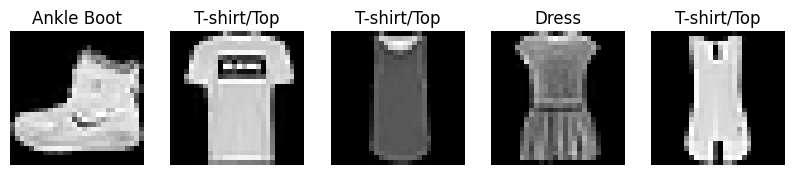

In [ ]:
# Normalize and reshape
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

# Display sample images
plt.figure(figsize=(10,3))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i].reshape(28,28),cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()


In [ ]:
# Build CNN model
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train model
EPOCHS=10
BATCH_SIZE=64
history=model.fit(
    X_train,y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2
)
print("Final Training Accuracy:",history.history['accuracy'][-1])


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 59s 68ms/step - accuracy: 0.8125 - loss: 0.5179 - val_accuracy: 0.8625 - val_loss: 0.3902
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.8765 - loss: 0.3413 - val_accuracy: 0.8779 - val_loss: 0.3301
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.8930 - loss: 0.2929 - val_accuracy: 0.8881 - val_loss: 0.3093
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 61ms/step - accuracy: 0.9039 - loss: 0.2602 - val_accuracy: 0.8942 - val_loss: 0.2855
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.9134 - loss: 0.2371 - val_accuracy: 0.9003 - val_loss: 0.2686
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.9222 - loss: 0.2111 - val_accuracy: 0.9082 - val_loss: 0.2511
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.9294 - loss: 0.1913 - val_accuracy: 0.9108 - val_loss: 0.2564
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 57ms/step - accuracy: 0.9356 - loss: 0.1732 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9033 - loss: 0.2765
Test Accuracy: 0.9032999873161316
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


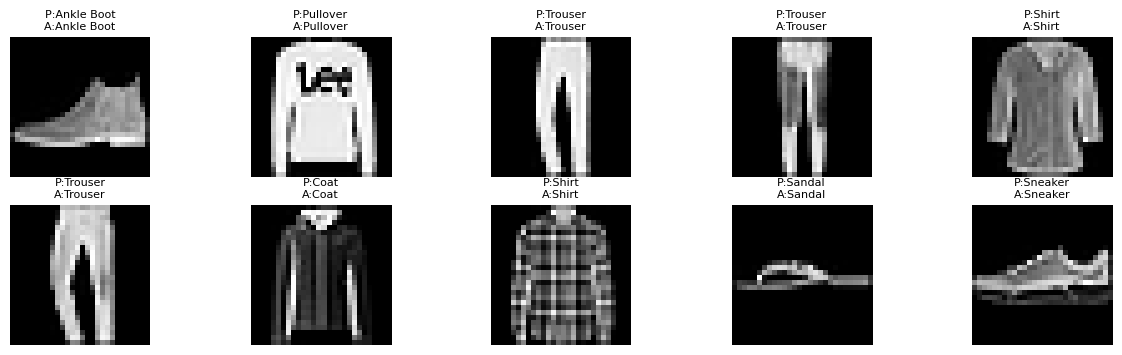

Confusion Matrix
[[771   0  29  17   5   2 170   0   6   0]
 [  3 980   1  12   1   0   2   0   1   0]
 [  8   0 854   6  55   0  76   0   1   0]
 [ 17   8  15 897  17   1  38   0   7   0]
 [  1   0  48  21 869   0  59   0   2   0]
 [  0   0   0   0   0 973   0  21   0   6]
 [ 62   0  68  17  72   0 772   0   9   0]
 [  0   0   0   0   0   7   0 977   0  16]
 [  2   0   2   3   3   2   3   5 979   1]
 [  1   0   0   0   0   4   0  34   0 961]]

Classification Report
              precision    recall  f1-score   support

 T-shirt/Top       0.89      0.77      0.83      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.84      0.85      0.85      1000
       Dress       0.92      0.90      0.91      1000
        Coat       0.85      0.87      0.86      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.69      0.77      0.73      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.97      0.98      0.9

In [ ]:
# Evaluate
test_loss,test_acc=model.evaluate(X_test,y_test)
print("Test Accuracy:",test_acc)

pred_probs=model.predict(X_test)
pred=np.argmax(pred_probs,axis=1)

# Show first 10 predictions
plt.figure(figsize=(15,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28),cmap='gray')
    plt.title(f'P:{class_names[pred[i]]}\nA:{class_names[y_test[i]]}',fontsize=8)
    plt.axis('off')
plt.show()

print("Confusion Matrix")
print(confusion_matrix(y_test,pred))

print("\nClassification Report")
print(classification_report(y_test,pred,target_names=class_names))


# Part 5 - Model Analysis

1. **Why CNN over ANN?** CNNs automatically learn spatial features using shared filters, require fewer parameters, and perform better on images.

2. **Purpose of Convolution Layer:** Extracts features such as edges, textures, and shapes using learnable filters.

3. **Why Max Pooling?** Reduces feature map size, decreases computation, and helps retain important features while reducing overfitting.

4. **Why Flatten?** Converts 2D feature maps into a 1D vector so Dense layers can process them.

5. **Why Softmax?** Converts output scores into class probabilities that sum to 1 for multiclass classification.

6. **How Adam helps?** Adam combines momentum and adaptive learning rates, resulting in faster convergence and stable training.
